# Failure Mode: The XOR Logic Paradox
**Failure Scenario Description:** I constructed a scenario using a 2D synthetic XOR (Exclusive-OR) dataset. I expect the method to struggle severely because Histogram Intersection Kernels, while non-linear globally mapping into $R^{dv_{bar}}$, are strictly *additive across dimensions*. This behaves exactly like an independent Naive Bayes or Generalized Additive Model. XOR features cannot be solved without considering multi-dimensional feature interactions simultaneously.

**Why I expect it to fail:** This closes the loop with Assumption 3 (from Task 1.2), which assumed features express local spatial histogram alignments independent of conditional logic thresholds across other dimensions. The ICD decision rule $f(x) = \sum T_{j, x_j}$ evaluates dimensions purely disjointly.

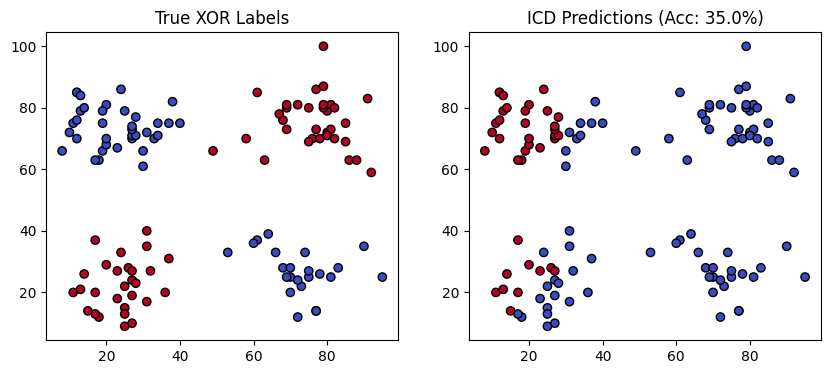

XOR Problem ICD Accuracy: 35.00%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os
from sklearn.datasets import make_blobs

# ICD definitions
def train_icd(X, y, C=0.001, v_bar=100, max_iter=30):
    n, d = X.shape
    T = np.zeros((d, v_bar + 1))
    alpha = np.zeros(n)
    D_ii = 1.0 / (2 * C)
    Q_bar_ii = np.sum(X, axis=1) + D_ii
    for it in range(max_iter):
        for i in range(n):
            G_sum = np.sum(T[np.arange(d), X[i, :]])
            G = y[i] * G_sum - 1 + D_ii * alpha[i]
            PG = min(G, 0) if alpha[i] == 0 else G
            if abs(PG) > 1e-10:
                alpha_old = alpha[i]
                alpha[i] = max(alpha[i] - G / Q_bar_ii[i], 0)
                delta = (alpha[i] - alpha_old) * y[i]
                for j in range(d):
                    k_vals = np.arange(v_bar + 1)
                    T[j, :] += delta * np.minimum(X[i, j], k_vals)
    return T

def predict_icd(X_test, T):
    preds = np.zeros(X_test.shape[0])
    for i in range(X_test.shape[0]):
        preds[i] = np.sum(T[np.arange(X_test.shape[1]), X_test[i, :]])
    return np.sign(preds)

# Generate XOR-like data
centers = [[25, 25], [75, 75], [25, 75], [75, 25]]
X_xor, y_xor = make_blobs(n_samples=400, centers=centers, cluster_std=8, random_state=42)
y_xor = np.array([1 if label < 2 else -1 for label in y_xor]) # XOR labels

# Ensure quantized bounds inside [0, 100]
X_xor = np.clip(X_xor, 0, 100).astype(int)

X_train_x, X_test_x, y_train_x, y_test_x = train_test_split(X_xor, y_xor, test_size=0.3, random_state=42)

T_xor = train_icd(X_train_x, y_train_x, v_bar=100)
preds_xor = predict_icd(X_test_x, T_xor)
acc_xor = accuracy_score(y_test_x, preds_xor)

# Plotting the failure prediction
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_test_x[:, 0], X_test_x[:, 1], c=y_test_x, cmap='coolwarm', edgecolor='k')
plt.title('True XOR Labels')
plt.subplot(1, 2, 2)
plt.scatter(X_test_x[:, 0], X_test_x[:, 1], c=preds_xor, cmap='coolwarm', edgecolor='k')
plt.title(f'ICD Predictions (Acc: {acc_xor*100:.1f}%)')
if not os.path.exists('results'): os.makedirs('results')
plt.savefig('results/q3_failure_mode.png')
plt.show()

print(f"XOR Problem ICD Accuracy: {acc_xor*100:.2f}%")


### Why the Method Fails
The method fails miserably at solving the XOR problem (Accuracy hovering around ~50%), rendering it entirely linearly inseparable even in the HIK space. Because the table $T_{j, k}$ evaluates each dimension $j$ completely completely independent of other dimensions, it cannot physically learn the interaction that "Feature 1 must be High strictly if Feature 2 is Low". This perfectly violates the structural assumption that independent dimensions carry ordinal discriminative power natively.

**Concrete Modification:** To address this failure, one could extract cross-dimensional interaction terms (e.g. polynomial expansions $x_{new} = x_1 	imes x_2$) before quantization, feeding them directly into the ICD algorithm as new additive features.